LIBRERIAS NECESARIAS


In [3]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix

DESCARGANDO BASE DE DATOS PUBLICOS

In [4]:
!git clone https://github.com/CodigoMaquina/code/
!unzip -q /content/code/piedra_papel_tijera_originales.zip
ruta = "/content/piedra_papel_tijera_originales"

fatal: destination path 'code' already exists and is not an empty directory.
replace piedra_papel_tijera_originales/paper/0.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace piedra_papel_tijera_originales/paper/1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace piedra_papel_tijera_originales/paper/10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


CREANDO CLASES

In [5]:
descripcion = ("paper", "rock", "scissors")
clases = {"paper" : 0, "rock" : 1, "scissors" : 2}
num_img_clase = 700
num_entrena = round(num_img_clase * 0.70)
num_prueba = round(num_img_clase * 0.30)

Cargar datos de Entrenamiento

In [6]:
imagenes_entrena = np.empty((num_entrena * len(clases), 200, 300, 3), dtype="uint8")
clases_entrena = np.empty(num_entrena * len(clases), dtype="uint8")
for i in range(num_entrena):
  for clase in clases:
    imagen = Image.open(ruta + "/" + clase + "/" + str(i) + ".png")
    indice_instancia = i + clases[clase] * num_entrena
    imagenes_entrena[indice_instancia] = np.array(imagen)
    clases_entrena[indice_instancia] = clases[clase]

Cargar datos de Prueba

In [7]:
imagenes_prueba = np.empty((num_prueba * len(clases), 200, 300, 3), dtype="uint8")
clases_prueba = np.empty(num_prueba * len(clases), dtype="uint8")
for i in range(num_entrena, num_img_clase):
  for clase in clases:
    imagen = Image.open(ruta + "/" + clase + "/" + str(i) + ".png")
    indice_instancia = i + clases[clase] * num_prueba - num_entrena
    imagenes_prueba[indice_instancia] = np.array(imagen)
    clases_prueba[indice_instancia] = clases[clase]

NORMALIZAR

In [8]:
imagenes_entrena = imagenes_entrena / 255.0
imagenes_prueba = imagenes_prueba / 255.0

print(f"Datos listos: {len(imagenes_entrena)} para entrenar y {len(imagenes_prueba)} para probar.")

Datos listos: 1470 para entrenar y 630 para probar.


1 capa convolucional

In [9]:
modelo_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 300, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2 capas convolucionales

In [10]:
modelo_2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 300, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'), # Segunda capa Conv
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

CNN con Dropout y más neuronas densas

In [11]:
modelo_3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 300, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'), # Más neuronas
    tf.keras.layers.Dropout(0.5),                  # Capa Dropout
    tf.keras.layers.Dense(3, activation='softmax')
])

Compilamos los 3 modelos

In [12]:
for modelo in [modelo_1, modelo_2, modelo_3]:
    modelo.compile(optimizer='adam',
                   loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                   metrics=['accuracy'])

print("ALFIN SE EJECUTO BIEN")

ALFIN SE EJECUTO BIEN


ENTRENAMOS LOS MODELOS

In [13]:
epocas = 3

print("--- ENTRENANDO MODELO 1 (1 Capa Convolucional) ---")
h1 = modelo_1.fit(imagenes_entrena, clases_entrena, epochs=epocas, validation_data=(imagenes_prueba, clases_prueba), verbose=1)

print("\n--- ENTRENANDO MODELO 2 (2 Capas Convolucionales) ---")
h2 = modelo_2.fit(imagenes_entrena, clases_entrena, epochs=epocas, validation_data=(imagenes_prueba, clases_prueba), verbose=1)

print("\n--- ENTRENANDO MODELO 3 (Dropout y +Neuronas) ---")
h3 = modelo_3.fit(imagenes_entrena, clases_entrena, epochs=epocas, validation_data=(imagenes_prueba, clases_prueba), verbose=1)

--- ENTRENANDO MODELO 1 (1 Capa Convolucional) ---
Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.5177 - loss: 3.9602 - val_accuracy: 0.8032 - val_loss: 0.6018
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8204 - loss: 0.5157 - val_accuracy: 0.7651 - val_loss: 0.6287
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8422 - loss: 0.4763 - val_accuracy: 0.8540 - val_loss: 0.4437

--- ENTRENANDO MODELO 2 (2 Capas Convolucionales) ---
Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 164s 4s/step - accuracy: 0.6218 - loss: 1.2398 - val_accuracy: 0.8270 - val_loss: 0.5033
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 171s 4s/step - accuracy: 0.8762 - loss: 0.3867 - val_accuracy: 0.8794 - val_loss: 0.3244
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.9333 - loss: 0.2040 - val_accuracy: 0.9175 - val_loss: 0.2181

--- ENTRENANDO MODELO 3 (Dropout y +Neuronas) ---
Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 177s 4s/step - accuracy: 0.6122 - loss: 1.4928 - val_

Comparación de Accuracy, Loss y Errores

In [14]:
#Loss y Accuracy
loss1, acc1 = modelo_1.evaluate(imagenes_prueba, clases_prueba, verbose=0)
loss2, acc2 = modelo_2.evaluate(imagenes_prueba, clases_prueba, verbose=0)
loss3, acc3 = modelo_3.evaluate(imagenes_prueba, clases_prueba, verbose=0)

#cantidad de errores
pred1 = np.argmax(modelo_1.predict(imagenes_prueba, verbose=0), axis=1)
pred2 = np.argmax(modelo_2.predict(imagenes_prueba, verbose=0), axis=1)
pred3 = np.argmax(modelo_3.predict(imagenes_prueba, verbose=0), axis=1)

err1 = np.sum(pred1 != clases_prueba)
err2 = np.sum(pred2 != clases_prueba)
err3 = np.sum(pred3 != clases_prueba)
total = len(clases_prueba)

print("-" * 60)
print(" COMPARACIÓN FINAL DE LOS 3 MODELOS")
print("-" * 60)
print(f"Modelo 1 (Básica) -> Loss: {loss1:.4f} | Accuracy: {acc1:.4f} | Errores: {err1} de {total}")
print(f"Modelo 2 (2 Capas)-> Loss: {loss2:.4f} | Accuracy: {acc2:.4f} | Errores: {err2} de {total}")
print(f"Modelo 3 (Dropout)-> Loss: {loss3:.4f} | Accuracy: {acc3:.4f} | Errores: {err3} de {total}")

------------------------------------------------------------
 COMPARACIÓN FINAL DE LOS 3 MODELOS
------------------------------------------------------------
Modelo 1 (Básica) -> Loss: 0.4437 | Accuracy: 0.8540 | Errores: 92 de 630
Modelo 2 (2 Capas)-> Loss: 0.2181 | Accuracy: 0.9175 | Errores: 52 de 630
Modelo 3 (Dropout)-> Loss: 0.2394 | Accuracy: 0.9048 | Errores: 60 de 630


Clases más confundidas


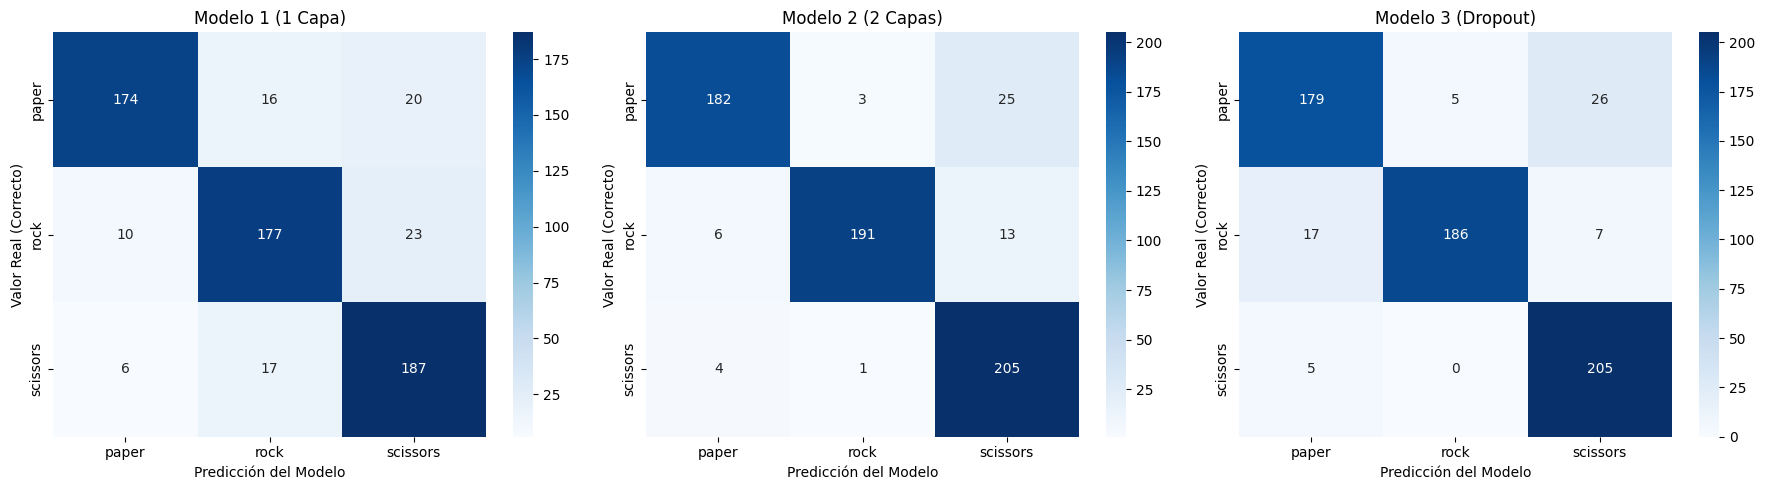

=> ANÁLISIS: Observa los números fuera de la diagonal azul oscuro.
=> Si ves un número alto cruzando 'rock' real con 'paper' predicción, significa que el modelo confunde esas dos clases.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
modelos_preds = [pred1, pred2, pred3]
titulos = ["Modelo 1 (1 Capa)", "Modelo 2 (2 Capas)", "Modelo 3 (Dropout)"]

for i in range(3):
    matriz = confusion_matrix(clases_prueba, modelos_preds[i])
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=descripcion, yticklabels=descripcion)
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Predicción del Modelo')
    axes[i].set_ylabel('Valor Real (Correcto)')

plt.tight_layout()
plt.show()

print("=> ANÁLISIS: Observa los números fuera de la diagonal azul oscuro.")
print("=> Si ves un número alto cruzando 'rock' real con 'paper' predicción, significa que el modelo confunde esas dos clases.")